### **Essay Writer**

In [5]:
from dotenv import load_dotenv, find_dotenv
import os, openai
from langchain_openai import ChatOpenAI
from tavily import TavilyClient

_ = load_dotenv(find_dotenv())
openai.api_key = os.environ['OPENAI_API_KEY']

chat = ChatOpenAI(model = 'gpt-3.5-turbo', temperature = 0)
tavily = TavilyClient(api_key = os.environ['TAVILY_API_KEY'])

In [6]:
PLAN_PROMPT = '''You are an expert writer tasked with writing a high level outline of an essay. \
Write such an outline for the user provided topic. Give an outline of the essay along with any relevant notes \
or instructions for the sections.'''

WRITER_PROMPT = '''You are an essay assistant tasked with writing excellent 5-paragraph essays.\
Generate the best essay possible for the user's request and the initial outline. \
If the user provides critique, respond with a revised version of your previous attempts. \
Utilize all the information below as needed: 

------

{content}'''

REFLECTION_PROMPT = '''You are a teacher grading an essay submission. \
Generate critique and recommendations for the user's submission. \
Provide detailed recommendations, including requests for length, depth, style, etc.'''

RESEARCH_PLAN_PROMPT = '''You are a researcher charged with providing information that can \
be used when writing the following essay. Generate a list of search queries that will gather \
any relevant information. Only generate 3 queries max.'''

RESEARCH_CRITIQUE_PROMPT = '''You are a researcher charged with providing information that can \
be used when making any requested revisions (as outlined below). \
Generate a list of search queries that will gather any relevant information. Only generate 3 queries max.'''


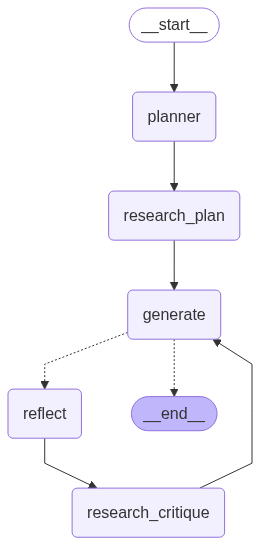

In [22]:
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict, Annotated, List, Literal
from langchain_core.pydantic_v1 import BaseModel
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, END
from IPython.display import display, Image
import json

class Queries(BaseModel):
    queries: List[str]

memory = MemorySaver()

class AgentState(TypedDict):
    task: str
    plan: str
    draft: str
    critique: str
    content: List[str]
    revision_number: int
    max_revisions: int

def plan_node(state: AgentState):
    messages = [
        SystemMessage(content = PLAN_PROMPT), 
        HumanMessage(content = state['task'])
    ]
    response = chat.invoke(messages)
    return {'plan': response.content}

def research_plan_node(state: AgentState):
    queries = chat.with_structured_output(Queries, method = 'function_calling').invoke([
        SystemMessage(content = RESEARCH_PLAN_PROMPT),
        HumanMessage(content = state['task'])
    ])

    content = state.get('content', [])
    for q in queries.queries:
        response = tavily.search(query = q, max_results = 2)
        for r in response['results']:
            content.append(r['content'])
    return {'content': content}

def generation_node(state: AgentState):
    content = '\n\n'.join(state.get('content', []))
    user_message = HumanMessage(
        content = f"{state['task']}\n\nHere is my plan:\n\n{state['plan']}"
    )
    messages = [
        SystemMessage(
            content = WRITER_PROMPT.format(content = content)
        ),
        user_message
    ]
    response = chat.invoke(messages)
    return {
        'draft': response.content,
        'revision_number': state.get('revision_number', 1) + 1
    }

def reflection_node(state: AgentState):
    messages = [
        SystemMessage(content = REFLECTION_PROMPT), 
        HumanMessage(content = state['draft'])
    ]
    response = chat.invoke(messages)
    return {'critique': response.content}

def research_critique_node(state: AgentState):
    queries = chat.with_structured_output(Queries, method = 'function_calling').invoke([
        SystemMessage(content = RESEARCH_CRITIQUE_PROMPT),
        HumanMessage(content = state['critique'])
    ])
    content = state['content'] or []
    for q in queries.queries:
        response = tavily.search(query = q, max_results = 2)
        for r in response['results']:
            content.append(r['content'])
    return {'content': content}

def should_continue(state) -> Literal['reflect', END]:
    if state['revision_number'] > state['max_revisions']:
        return END
    return 'reflect'

# Build the graph
builder = StateGraph(AgentState)
builder.add_node('planner', plan_node)
builder.add_node('research_plan', research_plan_node)
builder.add_node('generate', generation_node)
builder.add_node('reflect', reflection_node)
builder.add_node('research_critique', research_critique_node)

builder.set_entry_point('planner')
builder.add_edge('planner', 'research_plan')
builder.add_edge('research_plan', 'generate')
builder.add_conditional_edges('generate', should_continue)
builder.add_edge('reflect', 'research_critique')
builder.add_edge('research_critique', 'generate')

graph = builder.compile(checkpointer=memory)

# Display the graph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    print("Could not display graph image")

In [23]:
thread = {'configurable': {'thread_id': '1'}}

for s in graph.stream({
    'task': 'what is love?',
    'max_revisions': 2,
    'revision_number': 0
}, thread):
    print(s)

{'planner': {'plan': "I. Introduction\n    A. Definition of love\n    B. Importance of understanding love\n    C. Thesis statement: Exploring the multifaceted nature of love\n\nII. Historical Perspectives on Love\n    A. Ancient Greek concepts of love (Agape, Eros, Philia)\n    B. Love in religious and spiritual contexts\n    C. Evolution of the concept of love through different cultures and time periods\n\nIII. Psychological and Scientific Perspectives on Love\n    A. Theories of love (attachment theory, triangular theory of love)\n    B. Neurobiological basis of love\n    C. Love as a social and evolutionary construct\n\nIV. Philosophical Perspectives on Love\n    A. Love as a virtue (Aristotle)\n    B. Existentialist views on love (Sartre, de Beauvoir)\n    C. Love and ethics\n\nV. Cultural and Societal Influences on Love\n    A. Romantic love in literature and media\n    B. Changing perceptions of love in modern society\n    C. Impact of technology on love and relationships\n\nVI. 